# Preprocessing

A lot of missing values in the merged dataset. For time series it is crucial to have continuous data, so we need to fill in the missing values. Also we will look at outliers and cross reference them with real world events to see if they are valid or measurement errors.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

In [14]:
df = pd.read_csv("../data/processed/merged/merged_all_years.csv")
df.head()

,year,month,day,hour,day_of_week,holiday,before_holiday,consumption_gasnet,consumption_jmpnet,consumption_smpnet,...,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,traded_volume_mwh,weighted_avg_price_eur_mwh,min_price_eur_mwh,max_price_eur_mwh
0,2013,1,1,0,1,1,0,309647.0,266965.0,165229.0,...,-2.8195,-3.640714,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,2013,1,1,1,1,1,0,317580.0,268874.0,144587.0,...,-3.3695,-4.358559,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,2013,1,1,2,1,1,0,306847.0,264634.0,159128.0,...,-3.8695,-5.120251,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,2013,1,1,3,1,1,0,311308.0,258091.0,158021.0,...,-4.2695,-5.809683,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2013,1,1,4,1,1,0,313706.0,266043.0,158496.0,...,-4.5195,-6.283553,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


# Outliers

In [15]:
WEATHER_VARIABLES = [
    "temperature_2m",
    "wind_gusts_10m",
    "wind_direction_100m",
    "wind_direction_10m",
    "wind_speed_100m",
    "wind_speed_10m",
    "weather_code",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "snow_depth",
]

DATETIME_VARIABLES = [
    "year",
    "month",
    "day",
    "hour",
    "before_holiday",
    "holiday",
    "day_of_week",
]

PRICE_VARIABLES = [c for c in df.columns if c.endswith("_mwh")]

TOTAL_CONSUMPTION_COL = "consumption_total"

In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [
    c
    for c in num_cols
    if c not in WEATHER_VARIABLES
    and c not in DATETIME_VARIABLES
    and c not in PRICE_VARIABLES
    and c != TOTAL_CONSUMPTION_COL
]

In [17]:
outlier_rows = []
for col in num_cols:
    s = df[col].dropna()
    n_nonnull = len(s)
    if n_nonnull == 0:
        outlier_rows.append((col, 0, 0.0, np.nan, np.nan))
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    multiplier = 1.5
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    out_count = int(((df[col] < lower) | (df[col] > upper)).sum())

    out_pct = 100 * out_count / n_nonnull
    outlier_rows.append((col, out_count, round(out_pct, 4), lower, upper))

outliers_df = (
    pd.DataFrame(
        outlier_rows,
        columns=[
            "column",
            "outlier_count",
            "outlier_pct",
            "lower_bound",
            "upper_bound",
        ],
    )
    .sort_values("outlier_count", ascending=False)
    .reset_index(drop=True)
)

display(outliers_df)
print(
    "\nTotal outlier instances (sum over columns):",
    int(outliers_df["outlier_count"].sum()),
)

,column,outlier_count,outlier_pct,lower_bound,upper_bound
0,consumption_vcpnet,242,0.2125,-85159.75,258154.25
1,consumption_smpnet,189,0.1659,-88001.00,385455.00
2,consumption_gasnet,91,0.0799,-154384.50,742059.50
3,consumption_jmpnet,63,0.0553,-234281.50,575530.50



Total outlier instances (sum over columns): 585


In [18]:
records = []

for _, r in outliers_df.iterrows():
    col = r["column"]
    lower, upper = r["lower_bound"], r["upper_bound"]
    mask = df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    if not mask.any():
        continue

    subset = df.loc[mask, ["year", "month", "day", "hour", col]].copy()
    subset = subset.reset_index().rename(columns={"index": "orig_index", col: "value"})
    subset["timestamp"] = pd.to_datetime(subset[["year", "month", "day", "hour"]])
    subset["column"] = col
    subset["lower_bound"] = lower
    subset["upper_bound"] = upper

    # round the reported value for easier reading
    subset["value"] = subset["value"].round(0).astype(int)
    records.append(
        subset[
            ["orig_index", "timestamp", "column", "value", "lower_bound", "upper_bound"]
        ]
    )

if records:
    # sort by absolute value (largest absolute deviations first)
    outlier_entries = (
        pd.concat(records)
        .sort_values("value", key=lambda s: s.abs(), ascending=False)
        .reset_index(drop=True)
    )

    # format numeric columns with thousands separators for easier reading
    fmt = {"value": "{:,.0f}", "lower_bound": "{:,.0f}", "upper_bound": "{:,.0f}"}
    display(
        outlier_entries.style.format(fmt).set_properties(
            **{"text-align": "right"}, subset=["value", "lower_bound", "upper_bound"]
        )
    )

,orig_index,timestamp,column,value,lower_bound,upper_bound
0,27587,2016-02-24 11:00:00,consumption_gasnet,"2,000,187,846","-154,384","742,060"
1,27925,2016-03-09 13:00:00,consumption_gasnet,"1,705,450,767","-154,384","742,060"
2,80012,2022-02-16 20:00:00,consumption_gasnet,"1,000,432,665","-154,384","742,060"
3,80011,2022-02-16 19:00:00,consumption_gasnet,"1,000,429,371","-154,384","742,060"
4,80006,2022-02-16 14:00:00,consumption_gasnet,"1,000,424,694","-154,384","742,060"
5,27590,2016-02-24 14:00:00,consumption_gasnet,"1,000,298,543","-154,384","742,060"
6,27609,2016-02-25 09:00:00,consumption_smpnet,"1,000,285,509","-88,001","385,455"
7,64525,2020-05-12 13:00:00,consumption_gasnet,"1,000,247,826","-154,384","742,060"
8,66030,2020-07-14 06:00:00,consumption_smpnet,"999,910,060","-88,001","385,455"
9,63604,2020-04-04 04:00:00,consumption_smpnet,"900,159,335","-88,001","385,455"


In [19]:
# count outlier entries before / after the Russia–Ukraine conflict (start: 2022-02-24)
conflict_date = pd.Timestamp("2022-02-24")

before = outlier_entries[outlier_entries["timestamp"] < conflict_date]
after = outlier_entries[outlier_entries["timestamp"] >= conflict_date]

total_before = len(before)
total_after = len(after)

per_column = (
    pd.concat(
        [
            before.groupby("column").size().rename("before"),
            after.groupby("column").size().rename("after"),
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
per_column["total"] = per_column.sum(axis=1)
per_column = per_column.sort_values("total", ascending=False)

print(f"Conflict date used: {conflict_date.date()}")
print(
    f"Outlier entries — before: {total_before}, after: {total_after}, total: {total_before + total_after}"
)
per_column

Conflict date used: 2022-02-24
Outlier entries — before: 568, after: 17, total: 585


,before,after,total
column,,,
consumption_vcpnet,241,1,242
consumption_smpnet,173,16,189
consumption_gasnet,91,0,91
consumption_jmpnet,63,0,63


# Missing values

In [20]:
missing_values = pd.DataFrame(
    {
        "Column": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    }
)
missing_values = (
    missing_values[missing_values["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
    .reset_index(drop=True)
)
missing_values["Missing_Percentage"] = missing_values["Missing_Percentage"].round(3)
missing_values

,Column,Missing_Count,Missing_Percentage
0,weighted_avg_price_eur_mwh,1728,1.516
1,min_price_eur_mwh,1728,1.516
2,max_price_eur_mwh,1728,1.516
3,traded_volume_mwh,312,0.274
4,consumption_gasnet,114,0.100
5,consumption_jmpnet,55,0.048
6,consumption_vcpnet,53,0.047
7,consumption_smpnet,39,0.034
8,consumption_total,32,0.028


In [21]:
neg_summary = []
for c in num_cols:
    neg_mask = df[c] < 0
    neg_count = int(neg_mask.sum())
    neg_pct = 100 * neg_count / len(df) if len(df) else 0.0
    min_val = df[c].min() if neg_count else None
    first_neg = df.index[neg_mask].min() if neg_count else pd.NaT
    last_neg = df.index[neg_mask].max() if neg_count else pd.NaT
    neg_summary.append((c, neg_count, round(neg_pct, 4), min_val, first_neg, last_neg))

neg_df = (
    pd.DataFrame(
        neg_summary,
        columns=[
            "column",
            "neg_count",
            "neg_pct",
            "min_value",
            "first_negative_ts",
            "last_negative_ts",
        ],
    )
    .sort_values("neg_count", ascending=False)
    .reset_index(drop=True)
)

neg_df

,column,neg_count,neg_pct,min_value,first_negative_ts,last_negative_ts
0,consumption_jmpnet,12,0.0105,-155111263.0,27596,27965
1,consumption_gasnet,1,0.0009,-91659614.0,27596,27596
2,consumption_smpnet,1,0.0009,-18321.0,85898,85898
3,consumption_vcpnet,1,0.0009,-4619.0,23001,23001


## Preprocessing implementation (conflict-aware, no row drops)

This section creates one cleaned dataset for modeling `consumption_total` while preserving the 2022 regime break.

Principles:
- keep every timestamp (no row deletion)
- correct only impossible values (e.g., negative consumption or broken spikes)
- impute missing/invalid values with one smarter regression method (Decision Tree)
- use surrounding context (previous/next hour, day, week) to estimate missing points
- export cleaned data + transparent preprocessing reports

In [22]:
WAR_START = pd.Timestamp("2022-02-24")
TARGET_COL = "consumption_total"
np.random.seed(42)

df_work = df.copy()

# robust datetime from components already present in merged dataset
df_work["datetime"] = pd.to_datetime(
    df_work[["year", "month", "day", "hour"]], errors="coerce"
)
df_work = df_work.sort_values("datetime").reset_index(drop=True)
df_work["row_id"] = np.arange(len(df_work), dtype=int)
df_work["is_war_period"] = (df_work["datetime"] >= WAR_START).astype(int)

consumption_cols = [c for c in df_work.columns if c.startswith("consumption_")]
numeric_cols = [
    c for c in df_work.select_dtypes(include=[np.number]).columns if c not in ["row_id"]
]

print(f"Rows: {len(df_work):,}")
print(f"Time range: {df_work['datetime'].min()} -> {df_work['datetime'].max()}")
print(f"Target: {TARGET_COL}")

Rows: 113,952
Time range: 2013-01-01 00:00:00 -> 2025-12-31 23:00:00
Target: consumption_total


In [23]:
# continuity checks (no row dropping, only reporting)
continuity_report = {}
continuity_report["duplicate_datetimes"] = int(df_work["datetime"].duplicated().sum())

expected_idx = pd.date_range(
    start=df_work["datetime"].min(),
    end=df_work["datetime"].max(),
    freq="h",
)
actual_idx = pd.DatetimeIndex(df_work["datetime"])
missing_timestamps = expected_idx.difference(actual_idx)
continuity_report["missing_hour_slots"] = int(len(missing_timestamps))
continuity_report["contains_na_datetime"] = bool(df_work["datetime"].isna().any())

continuity_report

{'duplicate_datetimes': 0,
 'missing_hour_slots': 0,
 'contains_na_datetime': False}

In [24]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    dt_values = pd.to_datetime(out["datetime"], errors="coerce")
    dt_index = pd.DatetimeIndex(dt_values)

    hour_arr = np.asarray(dt_index.hour, dtype=float)
    dow_arr = np.asarray(dt_index.dayofweek, dtype=float)
    month_arr = np.asarray(dt_index.month, dtype=float)
    week_arr = np.asarray(dt_index.strftime("%V"), dtype=float)

    out["day_of_year"] = np.asarray(dt_index.strftime("%j"), dtype=float)
    out["week_of_year"] = week_arr
    out["is_weekend"] = np.where(dow_arr >= 5, 1, 0).astype(int)

    # cyclical time encoding
    out["hour_sin"] = np.sin((2.0 * np.pi * hour_arr) / 24.0)
    out["hour_cos"] = np.cos((2.0 * np.pi * hour_arr) / 24.0)
    out["dow_sin"] = np.sin((2.0 * np.pi * dow_arr) / 7.0)
    out["dow_cos"] = np.cos((2.0 * np.pi * dow_arr) / 7.0)
    out["month_sin"] = np.sin((2.0 * np.pi * month_arr) / 12.0)
    out["month_cos"] = np.cos((2.0 * np.pi * month_arr) / 12.0)
    return out


def add_target_surrounding_features(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    out = frame.copy()
    # backward context
    out[f"{col}_lag_1"] = out[col].shift(1)
    out[f"{col}_lag_24"] = out[col].shift(24)
    out[f"{col}_lag_168"] = out[col].shift(168)
    # forward context (for offline preprocessing, gives "smart mean" from surroundings)
    out[f"{col}_lead_1"] = out[col].shift(-1)
    out[f"{col}_lead_24"] = out[col].shift(-24)
    out[f"{col}_lead_168"] = out[col].shift(-168)

    out[f"{col}_roll_24_mean"] = out[col].shift(1).rolling(24, min_periods=1).mean()
    out[f"{col}_roll_168_mean"] = out[col].shift(1).rolling(168, min_periods=1).mean()
    return out


def fit_decision_tree_imputer(
    X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series
):
    model = DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=20,
        random_state=42,
    )

    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)

    model.fit(X_train_imp, y_train)
    pred = model.predict(X_val_imp)
    mae = mean_absolute_error(y_val, pred)
    return imputer, model, float(mae)


def impute_single_column(frame: pd.DataFrame, target_col: str):
    work = add_target_surrounding_features(frame, target_col)

    base_feature_cols = [
        c
        for c in work.columns
        if c not in [target_col, "datetime", "row_id"]
        and pd.api.types.is_numeric_dtype(work[c])
    ]
    usable_feature_cols = [c for c in base_feature_cols if work[c].notna().any()]

    train_mask = work[target_col].notna()
    miss_mask = work[target_col].isna()

    if train_mask.sum() < 500 or miss_mask.sum() == 0 or len(usable_feature_cols) == 0:
        return frame[target_col], {
            "column": target_col,
            "model": "fallback_ffill_bfill",
            "masked_mae": np.nan,
            "n_missing_filled": int(miss_mask.sum()),
            "n_train": int(train_mask.sum()),
        }

    train_idx = work.index[train_mask]
    val_n = min(4000, max(300, int(0.2 * len(train_idx))))
    val_idx = pd.Index(
        np.random.choice(np.asarray(train_idx), size=val_n, replace=False)
    )
    fit_idx = train_idx.difference(val_idx)

    X_train = work.loc[fit_idx, usable_feature_cols]
    y_train = work.loc[fit_idx, target_col]
    X_val = work.loc[val_idx, usable_feature_cols]
    y_val = work.loc[val_idx, target_col]

    imputer, tree, masked_mae = fit_decision_tree_imputer(
        X_train, y_train, X_val, y_val
    )

    X_all_train = work.loc[train_mask, usable_feature_cols]
    y_all_train = work.loc[train_mask, target_col]
    X_all_train_imp = imputer.fit_transform(X_all_train)
    tree.fit(X_all_train_imp, y_all_train)

    out_series = frame[target_col].copy()
    if miss_mask.sum():
        X_missing = work.loc[miss_mask, usable_feature_cols]
        X_missing_imp = imputer.transform(X_missing)
        pred_missing = tree.predict(X_missing_imp)
        out_series.loc[miss_mask] = pred_missing

    # conservative fallback for start/end edges or any residual NaNs
    lag24 = work[f"{target_col}_lag_24"]
    lag168 = work[f"{target_col}_lag_168"]
    lead24 = work[f"{target_col}_lead_24"]
    out_series = out_series.fillna(lag24).fillna(lead24).fillna(lag168).ffill().bfill()

    report = {
        "column": target_col,
        "model": "decision_tree_surroundings",
        "masked_mae": round(masked_mae, 4),
        "n_missing_filled": int(miss_mask.sum()),
        "n_train": int(train_mask.sum()),
    }
    return out_series, report

In [25]:
# apply preprocessing: impossible-value correction + model-based imputation
df_prepared = add_time_features(df_work.copy())

component_consumption_cols = [
    c for c in consumption_cols if c != TARGET_COL and c.startswith("consumption_")
]

imputation_candidates = [
    c for c in numeric_cols if c != TARGET_COL and df_prepared[c].isna().any()
]
imputation_report_rows = []
correction_report_rows = []

for col in component_consumption_cols:
    if col not in df_prepared.columns:
        continue

    series = df_prepared[col]
    neg_mask = series < 0

    # broken spikes: very large isolated jumps (kept strict to avoid suppressing real conflict effects)
    abs_diff = series.diff().abs()
    diff_thr = abs_diff.quantile(0.999)
    val_thr = series.abs().quantile(0.999)
    spike_mask = (abs_diff > 15 * diff_thr) & (series.abs() > 8 * val_thr)

    impossible_mask = (neg_mask | spike_mask.fillna(False)) & series.notna()

    n_invalid = int(impossible_mask.sum())
    if n_invalid > 0:
        df_prepared.loc[impossible_mask, col] = np.nan

    correction_report_rows.append(
        {
            "column": col,
            "negative_count": int(neg_mask.sum()),
            "spike_count": int(spike_mask.fillna(False).sum()),
            "corrected_to_nan": n_invalid,
        }
    )

# include columns where new NaNs were introduced by impossible-value correction
imputation_candidates = sorted(
    set(
        imputation_candidates
        + [r["column"] for r in correction_report_rows if r["corrected_to_nan"] > 0]
    )
)

for col in imputation_candidates:
    imputed_series, rep = impute_single_column(df_prepared, col)
    df_prepared[col] = imputed_series
    imputation_report_rows.append(rep)

# recompute target from component consumptions (no model imputation on total)
df_prepared[TARGET_COL] = df_prepared[component_consumption_cols].sum(
    axis=1, min_count=1
)

imputation_report = (
    pd.DataFrame(imputation_report_rows)
    .sort_values(["n_missing_filled", "masked_mae"], ascending=[False, True])
    .reset_index(drop=True)
)
correction_report = (
    pd.DataFrame(correction_report_rows)
    .sort_values("corrected_to_nan", ascending=False)
    .reset_index(drop=True)
)

display(imputation_report)
display(correction_report.head(10))

,column,model,masked_mae,n_missing_filled,n_train
0,min_price_eur_mwh,decision_tree_surroundings,0.0535,1728,112224
1,weighted_avg_price_eur_mwh,decision_tree_surroundings,0.0700,1728,112224
2,max_price_eur_mwh,decision_tree_surroundings,0.1289,1728,112224
3,traded_volume_mwh,decision_tree_surroundings,25.8039,312,113640
4,consumption_gasnet,decision_tree_surroundings,18443.8255,125,113827
5,consumption_jmpnet,decision_tree_surroundings,5223.1130,72,113880
6,consumption_vcpnet,decision_tree_surroundings,3096.8936,54,113898
7,consumption_smpnet,decision_tree_surroundings,5029.5409,43,113909


,column,negative_count,spike_count,corrected_to_nan
0,consumption_jmpnet,12,6,17
1,consumption_gasnet,1,11,11
2,consumption_smpnet,1,3,4
3,consumption_vcpnet,1,0,1


In [26]:
# post-checks + export cleaned dataset and report tables
required_cols = [TARGET_COL]
post_missing = df_prepared[required_cols].isna().sum().to_dict()
row_count_ok = len(df_prepared) == len(df_work)

qa_summary = {
    "row_count_original": int(len(df_work)),
    "row_count_cleaned": int(len(df_prepared)),
    "row_count_preserved": bool(row_count_ok),
    "target_missing_after": int(post_missing[TARGET_COL]),
    "war_rows": int((df_prepared["datetime"] >= WAR_START).sum()),
    "prewar_rows": int((df_prepared["datetime"] < WAR_START).sum()),
}

display(qa_summary)

before_vs_after_missing = pd.DataFrame(
    {
        "column": numeric_cols,
        "missing_before": [int(df_work[c].isna().sum()) for c in numeric_cols],
        "missing_after": [int(df_prepared[c].isna().sum()) for c in numeric_cols],
    }
)
before_vs_after_missing = before_vs_after_missing[
    (before_vs_after_missing["missing_before"] > 0)
    | (before_vs_after_missing["missing_after"] > 0)
]
before_vs_after_missing = before_vs_after_missing.sort_values(
    ["missing_before", "missing_after"], ascending=[False, False]
).reset_index(drop=True)

display(before_vs_after_missing.head(20))

export_dir = Path("../data/preprocessed")
report_dir = export_dir / "reports"
report_dir.mkdir(parents=True, exist_ok=True)

# keep original column order + datetime/is_war_period for traceability
export_cols = list(df.columns) + ["datetime", "is_war_period", "row_id"]
df_export = df_prepared[export_cols].copy()

cleaned_path = export_dir / "merged_all_years_preprocessed.csv"
df_export.to_csv(cleaned_path, index=False)

imputation_report.to_csv(report_dir / "imputation_report.csv", index=False)
correction_report.to_csv(report_dir / "correction_report.csv", index=False)
before_vs_after_missing.to_csv(report_dir / "missing_before_after.csv", index=False)
pd.DataFrame([qa_summary]).to_csv(report_dir / "qa_summary.csv", index=False)

print(f"Saved cleaned dataset: {cleaned_path}")
print(f"Saved reports in: {report_dir}")

{'row_count_original': 113952,
 'row_count_cleaned': 113952,
 'row_count_preserved': True,
 'target_missing_after': 0,
 'war_rows': 33768,
 'prewar_rows': 80184}

,column,missing_before,missing_after
0,weighted_avg_price_eur_mwh,1728,0
1,min_price_eur_mwh,1728,0
2,max_price_eur_mwh,1728,0
3,traded_volume_mwh,312,0
4,consumption_gasnet,114,0
5,consumption_jmpnet,55,0
6,consumption_vcpnet,53,0
7,consumption_smpnet,39,0
8,consumption_total,32,0


Saved cleaned dataset: ..\data\preprocessed\merged_all_years_preprocessed.csv
Saved reports in: ..\data\preprocessed\reports


## Small EDA on preprocessed dataset

Quick checks to confirm trend behavior and war-period shift are preserved after preprocessing.

In [27]:
eda_df = df_export.copy()
eda_df["datetime"] = pd.to_datetime(eda_df["datetime"], errors="coerce")

eda_summary = pd.DataFrame(
    {
        "rows": [len(eda_df)],
        "start": [eda_df["datetime"].min()],
        "end": [eda_df["datetime"].max()],
        "target_min": [eda_df[TARGET_COL].min()],
        "target_median": [eda_df[TARGET_COL].median()],
        "target_max": [eda_df[TARGET_COL].max()],
        "target_mean_prewar": [
            eda_df.loc[eda_df["datetime"] < WAR_START, TARGET_COL].mean()
        ],
        "target_mean_war": [
            eda_df.loc[eda_df["datetime"] >= WAR_START, TARGET_COL].mean()
        ],
    }
)
display(eda_summary.round(3))

,rows,start,end,target_min,target_median,target_max,target_mean_prewar,target_mean_war
0,113952,2013-01-01,2025-12-31 23:00:00,0.0,636252.5,1.001126e+09,784066.712,630037.954


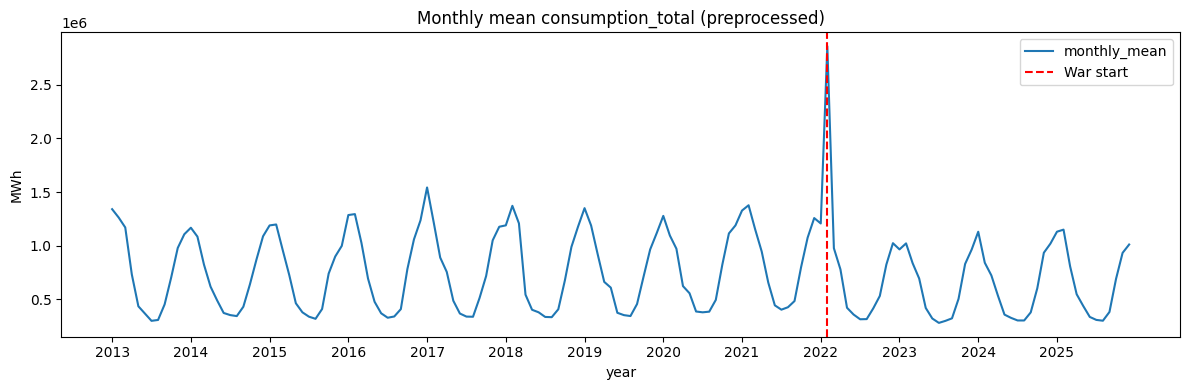

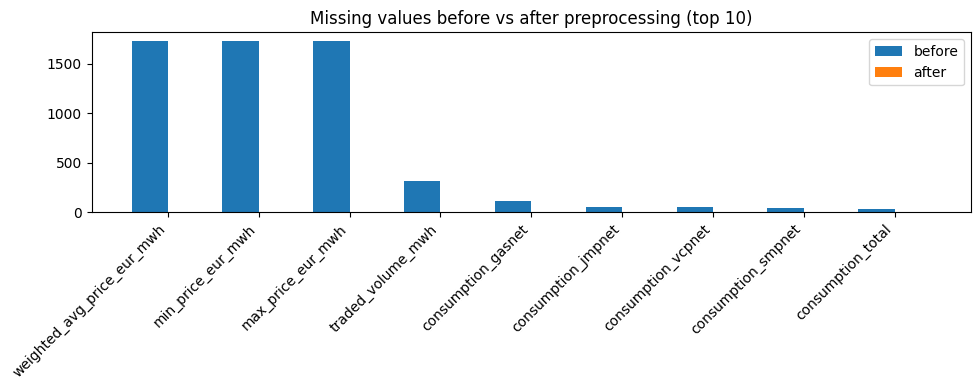

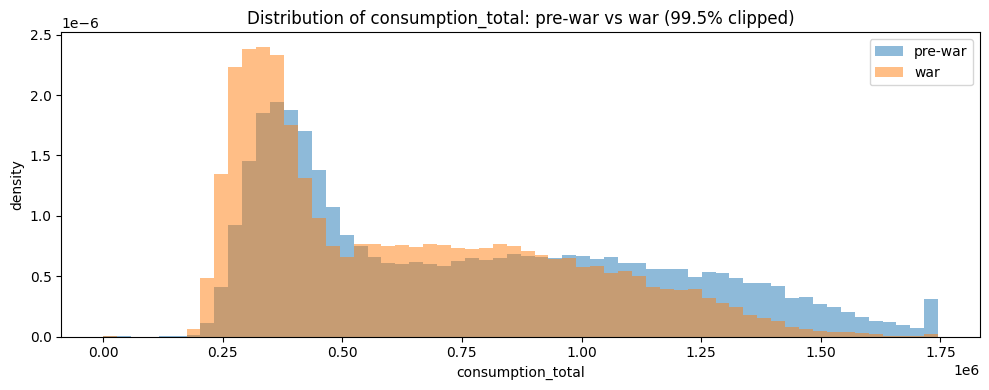

In [28]:
# 1) monthly target trend with conflict marker
monthly = (
    eda_df.set_index("datetime")[TARGET_COL]
    .resample("ME")
    .mean()
    .rename("monthly_mean")
)
x_month = np.arange(len(monthly), dtype=float)
y_month = monthly.to_numpy(dtype=float)
war_idx = float(np.searchsorted(monthly.index.to_numpy(), np.datetime64(WAR_START)))

plt.figure(figsize=(12, 4))
plt.plot(x_month, y_month, label="monthly_mean")
plt.axvline(x=war_idx, color="red", linestyle="--", linewidth=1.5, label="War start")

tick_pos = np.arange(0, len(monthly), 12, dtype=int)
tick_labels = [str(monthly.index[i])[:4] for i in tick_pos]
plt.xticks(tick_pos, tick_labels)
plt.title("Monthly mean consumption_total (preprocessed)")
plt.ylabel("MWh")
plt.xlabel("year")
plt.legend()
plt.tight_layout()
plt.show()

# 2) missing values before vs after for top columns
top_missing = before_vs_after_missing.head(10).copy()

plt.figure(figsize=(10, 4))
x = np.arange(len(top_missing))
w = 0.4
plt.bar(x - w / 2, top_missing["missing_before"], width=w, label="before")
plt.bar(x + w / 2, top_missing["missing_after"], width=w, label="after")
plt.xticks(x, top_missing["column"].astype(str).tolist(), rotation=45, ha="right")
plt.title("Missing values before vs after preprocessing (top 10)")
plt.legend()
plt.tight_layout()
plt.show()

# 3) target distribution pre-war vs war (clipped to 99.5% for readability)
pre = eda_df.loc[eda_df["datetime"] < WAR_START, TARGET_COL]
war = eda_df.loc[eda_df["datetime"] >= WAR_START, TARGET_COL]
upper_clip = float(eda_df[TARGET_COL].quantile(0.995))
pre_clip = pre.clip(upper=upper_clip)
war_clip = war.clip(upper=upper_clip)

plt.figure(figsize=(10, 4))
bins = 60
plt.hist(pre_clip, bins=bins, alpha=0.5, label="pre-war", density=True)
plt.hist(war_clip, bins=bins, alpha=0.5, label="war", density=True)
plt.title("Distribution of consumption_total: pre-war vs war (99.5% clipped)")
plt.xlabel("consumption_total")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()